# 01 — Data Understanding

## Project

**Should Marketing Professionals Learn Data Analytics?**

*A Machine Learning Analysis of Education, Technical Skills and Career Success*

## Objective

This project investigates whether education, professional preparation, technical skills and other career-related factors are associated with career success among professionals with a background in Marketing.

The analysis focuses specifically on individuals whose field of study is Marketing.

## Dataset

**Education & Career Success**

The dataset contains information about education, professional preparation, skills and career outcomes.

For this project, the analysis will be restricted to observations where:

`Field_of_Study = Marketing`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import csv

file_path = "../data/raw/education_career_success cvs.csv"

with open(file_path, "r", encoding="utf-8") as file:
    reader = csv.reader(file)
    rows = list(reader)

print("Number of rows: - 01_data_understanding.ipynb:9", len(rows))
print("Columns in header: - 01_data_understanding.ipynb:10", len(rows[0]))

for i, row in enumerate(rows):
    if len(row) != len(rows[0]):
        print("Problem on row: - 01_data_understanding.ipynb:14", i + 1)
        print("Number of columns: - 01_data_understanding.ipynb:15", len(row))
        print("Expected: - 01_data_understanding.ipynb:16", len(rows[0]))

Number of rows: - 01_data_understanding.ipynb:9 401
Columns in header: - 01_data_understanding.ipynb:10 19


In [8]:
import os

file_path = "../data/raw/education_career_success cvs.csv"

print("File exists: - 01_data_understanding.ipynb:5", os.path.exists(file_path))
print("Full path: - 01_data_understanding.ipynb:6", os.path.abspath(file_path))

File exists: - 01_data_understanding.ipynb:5 True
Full path: - 01_data_understanding.ipynb:6 c:\Users\teres\OneDrive\Desktop\ironhack\2 ironhack BOOTCAMP Data anaytics\1 Labs\Should-Marketing-Professionals-Learn-Data-Analytics-\data\raw\education_career_success cvs.csv


In [9]:
with open(file_path, "r", encoding="utf-8") as file:
    for i in range(5):
        print(file.readline().strip())

Student_ID,Age,Gender,High_School_GPA,SAT_Score,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
S001,22,Male,3.8,1450,3.6,Computer Science,3,7,2,8,7,3,85000,8,2,Mid,7,No
S002,24,Female,3.6,1380,3.4,Business,2,5,3,7,6,2,65000,7,3,Mid,6,No
S003,21,Male,3.9,1520,3.8,Engineering,4,9,4,9,8,4,120000,9,1,Senior,6,No
S004,23,Female,3.5,1300,3.2,Psychology,1,3,1,6,5,1,48000,6,4,Entry,8,No


In [11]:
df = pd.read_csv("../data/raw/education_career_success cvs.csv")

df.head()

,Student_ID,Age,Gender,High_School_GPA,SAT_Score,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
0,S001,22,Male,3.8,1450,3.6,Computer Science,3,7,2,8,7,3,85000,8,2,Mid,7,No
1,S002,24,Female,3.6,1380,3.4,Business,2,5,3,7,6,2,65000,7,3,Mid,6,No
2,S003,21,Male,3.9,1520,3.8,Engineering,4,9,4,9,8,4,120000,9,1,Senior,6,No
3,S004,23,Female,3.5,1300,3.2,Psychology,1,3,1,6,5,1,48000,6,4,Entry,8,No
4,S005,25,Male,3.7,1420,3.5,Medicine,2,6,2,8,7,3,95000,8,2,Mid,5,No


In [12]:
df.shape

(400, 19)

In [13]:
df.columns.tolist()

['Student_ID',
 'Age',
 'Gender',
 'High_School_GPA',
 'SAT_Score',
 'University_GPA',
 'Field_of_Study',
 'Internships_Completed',
 'Projects_Completed',
 'Certifications',
 'Soft_Skills_Score',
 'Networking_Score',
 'Job_Offers',
 'Starting_Salary',
 'Career_Satisfaction',
 'Years_to_Promotion',
 'Current_Job_Level',
 'Work_Life_Balance',
 'Entrepreneurship']

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             400 non-null    str    
 1   Age                    400 non-null    int64  
 2   Gender                 400 non-null    str    
 3   High_School_GPA        400 non-null    float64
 4   SAT_Score              400 non-null    int64  
 5   University_GPA         400 non-null    float64
 6   Field_of_Study         400 non-null    str    
 7   Internships_Completed  400 non-null    int64  
 8   Projects_Completed     400 non-null    int64  
 9   Certifications         400 non-null    int64  
 10  Soft_Skills_Score      400 non-null    int64  
 11  Networking_Score       400 non-null    int64  
 12  Job_Offers             400 non-null    int64  
 13  Starting_Salary        400 non-null    int64  
 14  Career_Satisfaction    400 non-null    int64  
 15  Years_to_Promotio

In [15]:
df["Field_of_Study"].value_counts()

Field_of_Study
Business            72
Engineering         58
Psychology          55
Computer Science    49
Law                 44
Marketing           44
Medicine            35
Arts                32
Finance              5
Education            3
Nursing              3
Name: count, dtype: int64

In [17]:
marketing_df = df[df["Field_of_Study"] == "Marketing"].copy()

marketing_df.shape

(44, 19)

In [18]:
marketing_df.head()

,Student_ID,Age,Gender,High_School_GPA,SAT_Score,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
10,S011,22,Male,3.3,1220,3.0,Marketing,1,3,1,6,5,1,40000,6,4,Entry,8,No
21,S022,24,Female,3.6,1360,3.4,Marketing,2,6,2,8,7,2,72000,7,3,Mid,7,No
30,S031,22,Male,3.4,1260,3.1,Marketing,1,4,1,7,6,1,46000,6,5,Entry,7,No
45,S046,22,Female,3.5,1290,3.2,Marketing,2,5,2,7,6,2,64000,7,4,Mid,7,No
52,S053,23,Male,3.4,1260,3.1,Marketing,1,4,1,7,6,1,46000,6,5,Entry,7,No


In [19]:
marketing_df.info()

<class 'pandas.DataFrame'>
Index: 44 entries, 10 to 399
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             44 non-null     str    
 1   Age                    44 non-null     int64  
 2   Gender                 44 non-null     str    
 3   High_School_GPA        44 non-null     float64
 4   SAT_Score              44 non-null     int64  
 5   University_GPA         44 non-null     float64
 6   Field_of_Study         44 non-null     str    
 7   Internships_Completed  44 non-null     int64  
 8   Projects_Completed     44 non-null     int64  
 9   Certifications         44 non-null     int64  
 10  Soft_Skills_Score      44 non-null     int64  
 11  Networking_Score       44 non-null     int64  
 12  Job_Offers             44 non-null     int64  
 13  Starting_Salary        44 non-null     int64  
 14  Career_Satisfaction    44 non-null     int64  
 15  Years_to_Promotion    

In [20]:
df["Field_of_Study"].value_counts()

Field_of_Study
Business            72
Engineering         58
Psychology          55
Computer Science    49
Law                 44
Marketing           44
Medicine            35
Arts                32
Finance              5
Education            3
Nursing              3
Name: count, dtype: int64

In [21]:
marketing_df = df[df["Field_of_Study"] == "Marketing"].copy()

marketing_df.shape

(44, 19)

In [22]:
marketing_df.head()

,Student_ID,Age,Gender,High_School_GPA,SAT_Score,University_GPA,Field_of_Study,Internships_Completed,Projects_Completed,Certifications,Soft_Skills_Score,Networking_Score,Job_Offers,Starting_Salary,Career_Satisfaction,Years_to_Promotion,Current_Job_Level,Work_Life_Balance,Entrepreneurship
10,S011,22,Male,3.3,1220,3.0,Marketing,1,3,1,6,5,1,40000,6,4,Entry,8,No
21,S022,24,Female,3.6,1360,3.4,Marketing,2,6,2,8,7,2,72000,7,3,Mid,7,No
30,S031,22,Male,3.4,1260,3.1,Marketing,1,4,1,7,6,1,46000,6,5,Entry,7,No
45,S046,22,Female,3.5,1290,3.2,Marketing,2,5,2,7,6,2,64000,7,4,Mid,7,No
52,S053,23,Male,3.4,1260,3.1,Marketing,1,4,1,7,6,1,46000,6,5,Entry,7,No


In [23]:
marketing_df.info()

<class 'pandas.DataFrame'>
Index: 44 entries, 10 to 399
Data columns (total 19 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Student_ID             44 non-null     str    
 1   Age                    44 non-null     int64  
 2   Gender                 44 non-null     str    
 3   High_School_GPA        44 non-null     float64
 4   SAT_Score              44 non-null     int64  
 5   University_GPA         44 non-null     float64
 6   Field_of_Study         44 non-null     str    
 7   Internships_Completed  44 non-null     int64  
 8   Projects_Completed     44 non-null     int64  
 9   Certifications         44 non-null     int64  
 10  Soft_Skills_Score      44 non-null     int64  
 11  Networking_Score       44 non-null     int64  
 12  Job_Offers             44 non-null     int64  
 13  Starting_Salary        44 non-null     int64  
 14  Career_Satisfaction    44 non-null     int64  
 15  Years_to_Promotion    

## Marketing Professionals

The original dataset contains 400 observations across 19 variables and 11 fields of study.

For this project, the analysis is restricted to the 44 observations where the field of study is Marketing.

This allows the project to focus specifically on the relationship between education, professional preparation, skills and career outcomes within Marketing.

Due to the relatively small sample size, the Machine Learning results will be interpreted cautiously and considered exploratory rather than broadly generalizable.

In [24]:
marketing_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,44.0,22.909091,1.459821,21.0,21.00,23.0,24.0,25.0
High_School_GPA,44.0,3.613636,0.106947,3.3,3.60,3.6,3.7,3.8
SAT_Score,44.0,1379.318182,71.735876,1220.0,1340.00,1380.0,1440.0,1520.0
University_GPA,44.0,3.431818,0.168126,3.0,3.40,3.4,3.5,3.7
Internships_Completed,44.0,2.522727,0.628347,1.0,2.00,3.0,3.0,3.0
Projects_Completed,44.0,6.113636,1.204949,3.0,5.00,6.0,7.0,8.0
Certifications,44.0,2.522727,0.628347,1.0,2.00,3.0,3.0,3.0
Soft_Skills_Score,44.0,7.818182,0.814769,6.0,7.00,8.0,8.0,9.0
Networking_Score,44.0,6.818182,0.814769,5.0,6.00,7.0,7.0,8.0
Job_Offers,44.0,2.613636,0.753778,1.0,2.00,3.0,3.0,4.0


In [25]:
marketing_df["Starting_Salary"].describe()

count        44.000000
mean      80318.181818
std       15108.557143
min       40000.000000
25%       72000.000000
50%       81000.000000
75%       90000.000000
max      102000.000000
Name: Starting_Salary, dtype: float64

In [26]:
marketing_df["Starting_Salary"].sort_values().to_list()

[40000,
 46000,
 46000,
 64000,
 64000,
 64000,
 64000,
 64000,
 68000,
 72000,
 72000,
 72000,
 72000,
 72000,
 76000,
 76000,
 76000,
 76000,
 78000,
 78000,
 78000,
 78000,
 84000,
 88000,
 88000,
 88000,
 88000,
 90000,
 90000,
 90000,
 90000,
 90000,
 90000,
 90000,
 94000,
 94000,
 94000,
 94000,
 94000,
 94000,
 102000,
 102000,
 102000,
 102000]

In [27]:
marketing_df["Current_Job_Level"].value_counts()

Current_Job_Level
Mid      41
Entry     3
Name: count, dtype: int64

In [28]:
marketing_df["Gender"].value_counts()

Gender
Female    27
Male      17
Name: count, dtype: int64

In [29]:
marketing_df["Entrepreneurship"].value_counts()

Entrepreneurship
No    44
Name: count, dtype: int64

In [30]:
numeric_columns = marketing_df.select_dtypes(include="number")

correlation_with_salary = (
    numeric_columns
    .corr()["Starting_Salary"]
    .sort_values(ascending=False)
)

correlation_with_salary

Starting_Salary          1.000000
University_GPA           0.916947
Career_Satisfaction      0.889081
Job_Offers               0.885040
Certifications           0.849258
Internships_Completed    0.849258
High_School_GPA          0.840661
Projects_Completed       0.838522
SAT_Score                0.831026
Networking_Score         0.828493
Soft_Skills_Score        0.828493
Age                      0.581267
Work_Life_Balance       -0.833713
Years_to_Promotion      -0.890776
Name: Starting_Salary, dtype: float64

In [31]:
marketing_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,44.0,22.909091,1.459821,21.0,21.00,23.0,24.0,25.0
High_School_GPA,44.0,3.613636,0.106947,3.3,3.60,3.6,3.7,3.8
SAT_Score,44.0,1379.318182,71.735876,1220.0,1340.00,1380.0,1440.0,1520.0
University_GPA,44.0,3.431818,0.168126,3.0,3.40,3.4,3.5,3.7
Internships_Completed,44.0,2.522727,0.628347,1.0,2.00,3.0,3.0,3.0
Projects_Completed,44.0,6.113636,1.204949,3.0,5.00,6.0,7.0,8.0
Certifications,44.0,2.522727,0.628347,1.0,2.00,3.0,3.0,3.0
Soft_Skills_Score,44.0,7.818182,0.814769,6.0,7.00,8.0,8.0,9.0
Networking_Score,44.0,6.818182,0.814769,5.0,6.00,7.0,7.0,8.0
Job_Offers,44.0,2.613636,0.753778,1.0,2.00,3.0,3.0,4.0


In [32]:
marketing_df["Starting_Salary"].describe()

count        44.000000
mean      80318.181818
std       15108.557143
min       40000.000000
25%       72000.000000
50%       81000.000000
75%       90000.000000
max      102000.000000
Name: Starting_Salary, dtype: float64

In [33]:
marketing_df["Starting_Salary"].sort_values().to_list()

[40000,
 46000,
 46000,
 64000,
 64000,
 64000,
 64000,
 64000,
 68000,
 72000,
 72000,
 72000,
 72000,
 72000,
 76000,
 76000,
 76000,
 76000,
 78000,
 78000,
 78000,
 78000,
 84000,
 88000,
 88000,
 88000,
 88000,
 90000,
 90000,
 90000,
 90000,
 90000,
 90000,
 90000,
 94000,
 94000,
 94000,
 94000,
 94000,
 94000,
 102000,
 102000,
 102000,
 102000]

In [34]:
marketing_df["Current_Job_Level"].value_counts()

Current_Job_Level
Mid      41
Entry     3
Name: count, dtype: int64

In [35]:
marketing_df["Gender"].value_counts()

Gender
Female    27
Male      17
Name: count, dtype: int64

In [36]:
numeric_columns = marketing_df.select_dtypes(include="number")

correlation_with_salary = (
    numeric_columns
    .corr()["Starting_Salary"]
    .sort_values(ascending=False)
)

correlation_with_salary

Starting_Salary          1.000000
University_GPA           0.916947
Career_Satisfaction      0.889081
Job_Offers               0.885040
Certifications           0.849258
Internships_Completed    0.849258
High_School_GPA          0.840661
Projects_Completed       0.838522
SAT_Score                0.831026
Networking_Score         0.828493
Soft_Skills_Score        0.828493
Age                      0.581267
Work_Life_Balance       -0.833713
Years_to_Promotion      -0.890776
Name: Starting_Salary, dtype: float64

### University GPA and Starting Salary

University GPA shows the strongest correlation with Starting Salary among the numerical variables. We visualize this relationship to assess whether higher academic performance is associated with higher starting salaries among Marketing professionals.

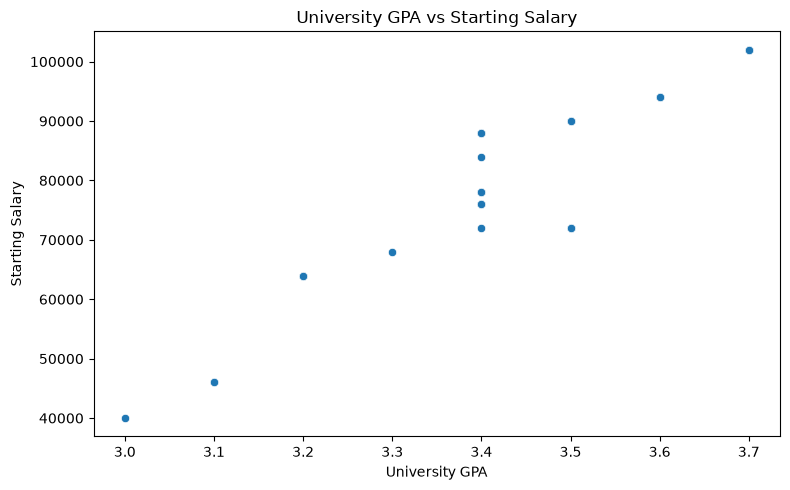

In [37]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=marketing_df,
    x="University_GPA",
    y="Starting_Salary"
)

plt.title("University GPA vs Starting Salary")
plt.xlabel("University GPA")
plt.ylabel("Starting Salary")
plt.tight_layout()

plt.show()

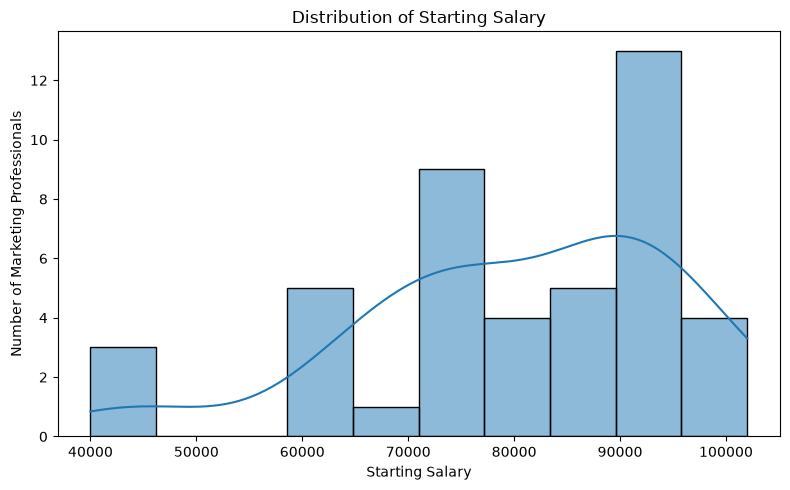

In [38]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=marketing_df,
    x="Starting_Salary",
    bins=10,
    kde=True
)

plt.title("Distribution of Starting Salary")
plt.xlabel("Starting Salary")
plt.ylabel("Number of Marketing Professionals")

plt.tight_layout()
plt.show()

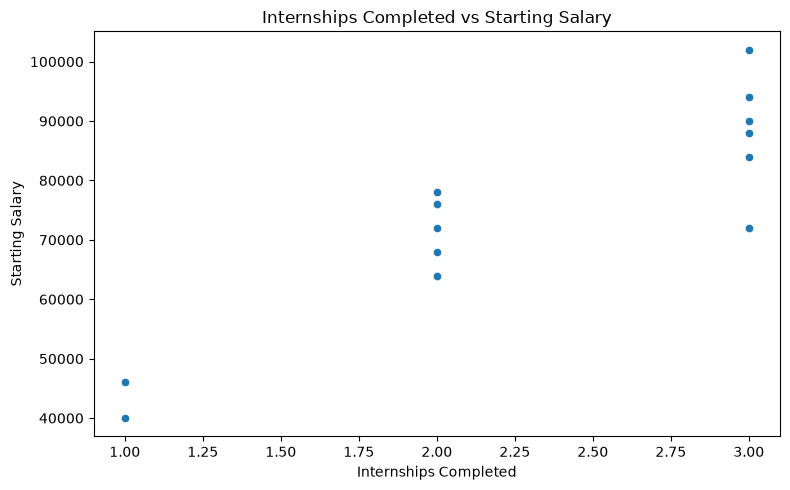

In [39]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=marketing_df,
    x="Internships_Completed",
    y="Starting_Salary"
)

plt.title("Internships Completed vs Starting Salary")
plt.xlabel("Internships Completed")
plt.ylabel("Starting Salary")

plt.tight_layout()
plt.show()

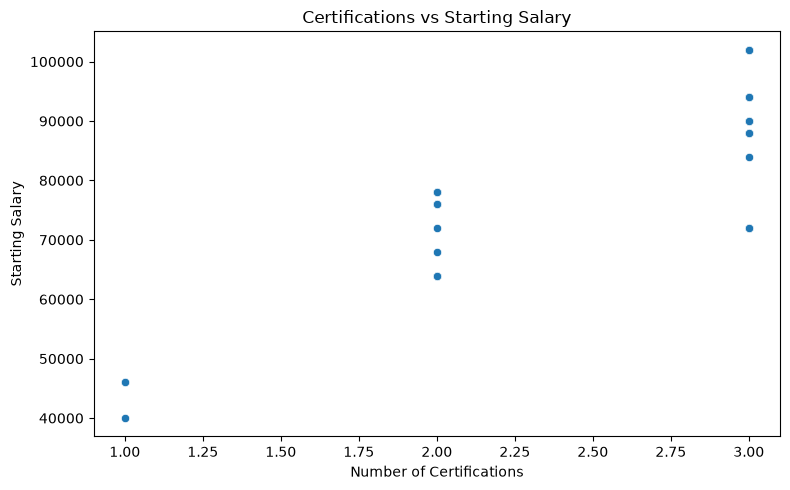

In [40]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=marketing_df,
    x="Certifications",
    y="Starting_Salary"
)

plt.title("Certifications vs Starting Salary")
plt.xlabel("Number of Certifications")
plt.ylabel("Starting Salary")

plt.tight_layout()
plt.show()

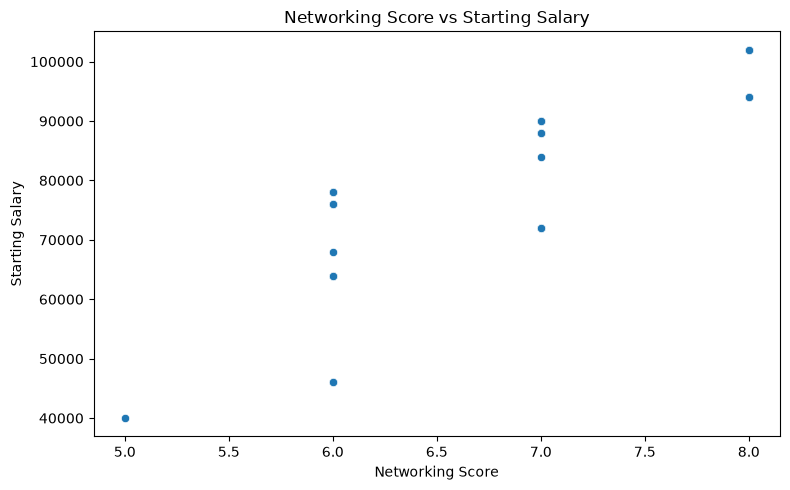

In [41]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=marketing_df,
    x="Networking_Score",
    y="Starting_Salary"
)

plt.title("Networking Score vs Starting Salary")
plt.xlabel("Networking Score")
plt.ylabel("Starting Salary")

plt.tight_layout()
plt.show()

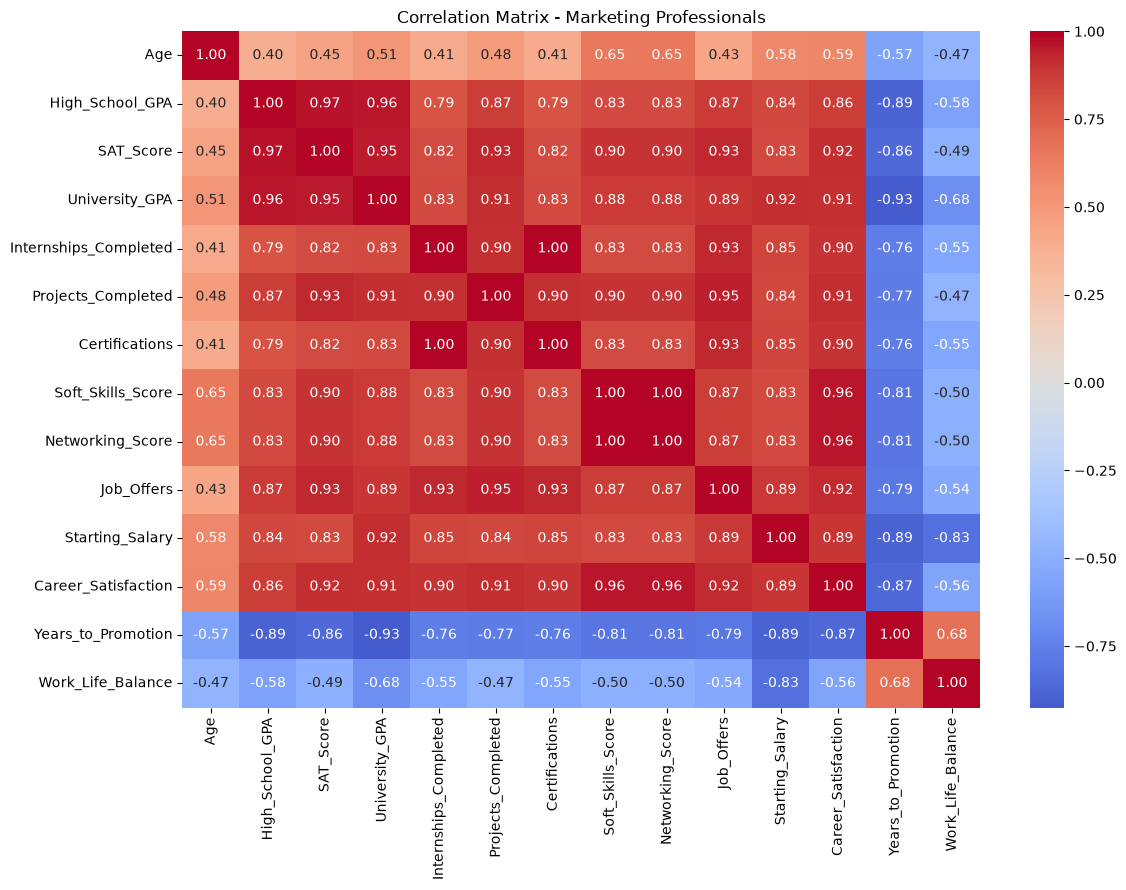

In [42]:
plt.figure(figsize=(12, 9))

correlation_matrix = marketing_df.select_dtypes(include="number").corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix - Marketing Professionals")
plt.tight_layout()

plt.show()

In [44]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   ---- ----------------------------------- 1.0/9.6 MB 5.3 MB/s eta 0:00:02
   --------- ------------------------------ 2.4/9.6 MB 5.5 MB/s eta 0:00:02
   --------------- ------------------------ 3.7/9.6 MB 6.0 MB/s eta 0:00:01
   ---------------------- ----------------- 5.5/9.6 MB 6.5 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.6 MB 6.5 MB/s eta 0:00:01
   ---------------------------------- ----- 8.4/9.6 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 6.6 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 6.4 MB/s  0:00:01

   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   ------------------


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X_vif = marketing_df.select_dtypes(include="number").drop(
    columns=["Starting_Salary"]
)

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)

c:\Users\teres\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,Feature,VIF
4,Internships_Completed,inf
6,Certifications,inf
7,Soft_Skills_Score,3.385589e+06
8,Networking_Score,2.589467e+06
2,SAT_Score,1.474218e+02
3,University_GPA,1.133241e+02
5,Projects_Completed,6.038575e+01
9,Job_Offers,5.223071e+01
1,High_School_GPA,4.919634e+01
10,Career_Satisfaction,4.429234e+01


In [46]:
marketing_vif_df = marketing_df.drop(
    columns=["Certifications", "Networking_Score"]
)

marketing_vif_df.shape

(44, 17)

In [47]:
X_vif = marketing_vif_df.select_dtypes(include="number").drop(
    columns=["Starting_Salary"]
)

vif = pd.DataFrame()
vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
2,SAT_Score,42688.845987
1,High_School_GPA,39563.854178
3,University_GPA,23062.053101
8,Career_Satisfaction,3447.918334
6,Soft_Skills_Score,3060.860551
10,Work_Life_Balance,833.973923
5,Projects_Completed,745.995730
0,Age,587.238366
7,Job_Offers,584.979688
4,Internships_Completed,276.961762


In [48]:
model_df = marketing_vif_df.drop(
    columns=[
        "High_School_GPA",
        "SAT_Score",
        "Career_Satisfaction",
        "Work_Life_Balance",
        "Job_Offers",
        "Age"
    ]
)

model_df.shape

(44, 11)

In [49]:
X_vif = model_df.select_dtypes(include="number").drop(
    columns=["Starting_Salary"]
)

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
3,Soft_Skills_Score,556.267931
0,University_GPA,490.428990
2,Projects_Completed,231.946515
1,Internships_Completed,99.584330
4,Years_to_Promotion,26.429154


In [50]:
model_vif_df = model_df.drop(columns=["Soft_Skills_Score"])

model_vif_df.shape

(44, 10)

In [51]:
X_vif = model_vif_df.select_dtypes(include="number").drop(
    columns=["Starting_Salary"]
)

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
2,Projects_Completed,192.860638
0,University_GPA,183.058711
1,Internships_Completed,99.393030
3,Years_to_Promotion,26.027220


In [52]:
model_vif_df = model_vif_df.drop(columns=["Projects_Completed"])

model_vif_df.shape

(44, 9)

In [53]:
X_vif = model_vif_df.select_dtypes(include="number").drop(
    columns=["Starting_Salary"]
)

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
0,University_GPA,113.264378
1,Internships_Completed,48.668252
2,Years_to_Promotion,23.236377


In [54]:
model_vif_df = model_vif_df.drop(columns=["University_GPA"])

model_vif_df.shape

(44, 8)

In [55]:
X_vif = model_vif_df.select_dtypes(include="number").drop(
    columns=["Starting_Salary"]
)

vif = pd.DataFrame()

vif["Feature"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values, i)
    for i in range(X_vif.shape[1])
]

vif.sort_values("VIF", ascending=False)

,Feature,VIF
1,Years_to_Promotion,5.044637
0,Internships_Completed,5.044637


In [56]:
model_vif_df.columns.tolist()

['Student_ID',
 'Gender',
 'Field_of_Study',
 'Internships_Completed',
 'Starting_Salary',
 'Years_to_Promotion',
 'Current_Job_Level',
 'Entrepreneurship']

In [57]:
X = model_vif_df.drop(
    columns=["Starting_Salary", "Student_ID"]
)

y = model_vif_df["Starting_Salary"]

X.shape, y.shape

((44, 6), (44,))

In [59]:
X_encoded = pd.get_dummies(
    X,
    columns=[
        "Gender",
        "Field_of_Study",
        "Current_Job_Level",
        "Entrepreneurship"
    ],
    drop_first=True
)

X_encoded.shape

(44, 4)

In [60]:
X_encoded.head()

,Internships_Completed,Years_to_Promotion,Gender_Male,Current_Job_Level_Mid
10,1,4,True,False
21,2,3,False,True
30,1,5,True,False
45,2,4,False,True
52,1,5,True,False


In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_encoded,
    y,
    test_size=0.2,
    random_state=42
)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((35, 4), (9, 4), (35,), (9,))

In [62]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[ 7390.41,-11954.34, 5742.01, 12251.14]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Internships_Completed','Years_to_Promotion','Gender_Male', 'Current_Job_Level_Mid']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.366e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [63]:
y_pred = model.predict(X_test)

y_pred

array([94175.79908676, 62876.71232877, 82221.46118721, 87963.47031963,
       87963.47031963, 94175.79908676, 37022.83105023, 94175.79908676,
       74831.05022831])

In [64]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²: - 01_data_understanding.ipynb:8", r2)
print("MAE: - 01_data_understanding.ipynb:9", mae)
print("RMSE: - 01_data_understanding.ipynb:10", rmse)

R²: - 01_data_understanding.ipynb:8 0.8998715316294701
MAE: - 01_data_understanding.ipynb:9 3526.6362252663685
RMSE: - 01_data_understanding.ipynb:10 5303.29842897271


In [65]:
print("R²: - 01_data_understanding.ipynb:1", r2)
print("MAE: - 01_data_understanding.ipynb:2", mae)
print("RMSE: - 01_data_understanding.ipynb:3", rmse)

R²: - 01_data_understanding.ipynb:1 0.8998715316294701
MAE: - 01_data_understanding.ipynb:2 3526.6362252663685
RMSE: - 01_data_understanding.ipynb:3 5303.29842897271


In [66]:
coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values("Coefficient", ascending=False)

,Feature,Coefficient
3,Current_Job_Level_Mid,12251.141553
0,Internships_Completed,7390.410959
2,Gender_Male,5742.009132
1,Years_to_Promotion,-11954.337900


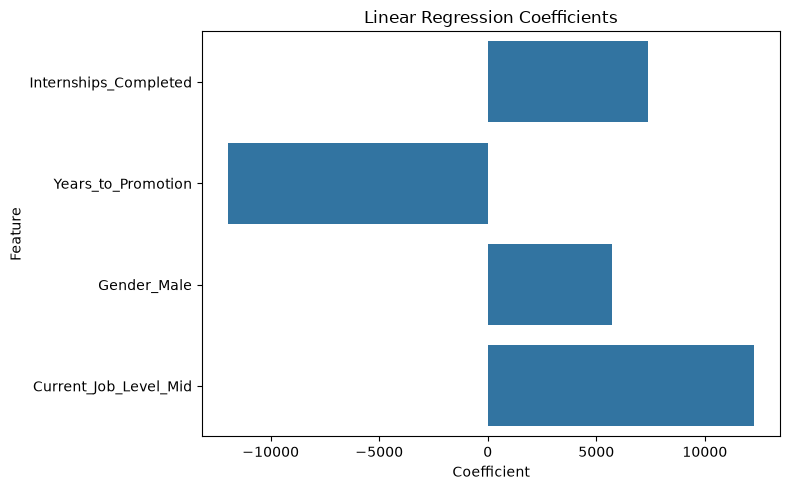

In [67]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Linear Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.tight_layout()

plt.show()

In [68]:
comparison = pd.DataFrame({
    "Actual_Salary": y_test.values,
    "Predicted_Salary": y_pred
})

comparison["Error"] = (
    comparison["Actual_Salary"] - comparison["Predicted_Salary"]
)

comparison

,Actual_Salary,Predicted_Salary,Error
0,94000,94175.799087,-175.799087
1,64000,62876.712329,1123.287671
2,72000,82221.461187,-10221.461187
3,90000,87963.470320,2036.529680
4,88000,87963.470320,36.529680
5,94000,94175.799087,-175.799087
6,46000,37022.831050,8977.168950
7,102000,94175.799087,7824.200913
8,76000,74831.050228,1168.949772


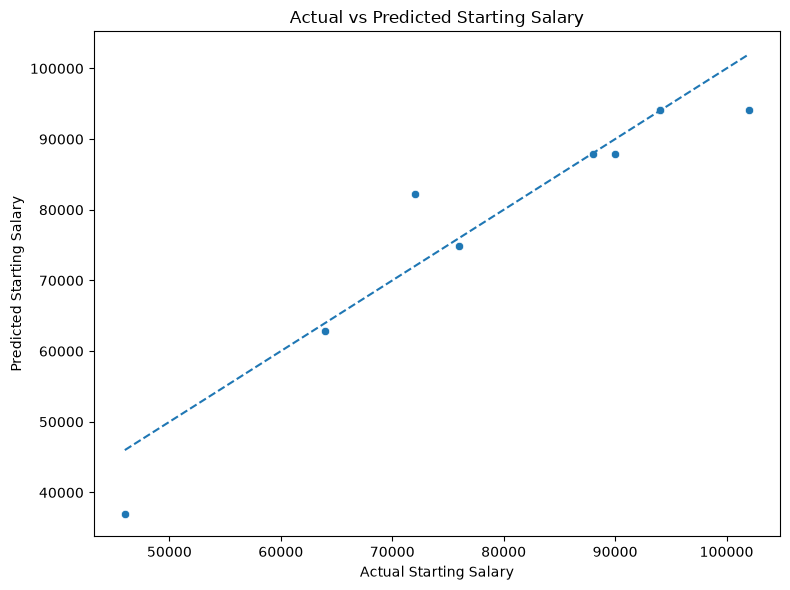

In [69]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=y_pred
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.title("Actual vs Predicted Starting Salary")
plt.xlabel("Actual Starting Salary")
plt.ylabel("Predicted Starting Salary")

plt.tight_layout()
plt.show()

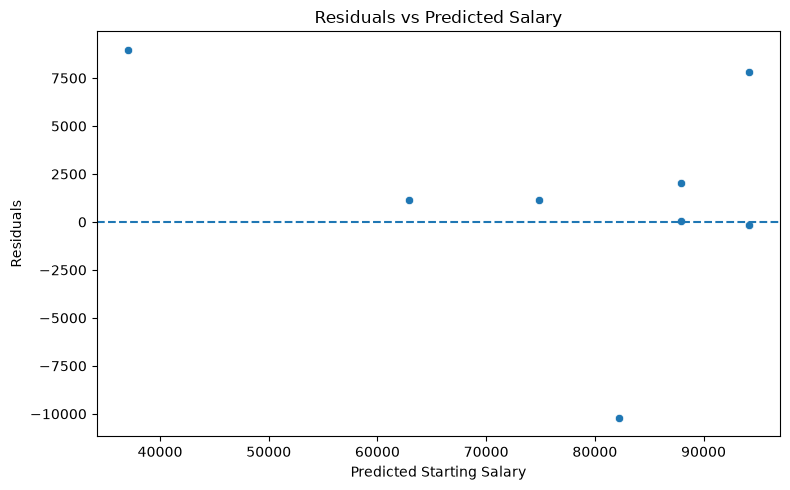

In [70]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x=y_pred,
    y=residuals
)

plt.axhline(0, linestyle="--")

plt.title("Residuals vs Predicted Salary")
plt.xlabel("Predicted Starting Salary")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

In [71]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_encoded,
    y,
    cv=5,
    scoring="r2"
)

print("R² scores: - 01_data_understanding.ipynb:11", cv_scores)
print("Mean R²: - 01_data_understanding.ipynb:12", cv_scores.mean())
print("Standard Deviation: - 01_data_understanding.ipynb:13", cv_scores.std())

R² scores: - 01_data_understanding.ipynb:11 [0.75066444 0.87309932 0.73271894 0.81230858 0.82533352]
Mean R²: - 01_data_understanding.ipynb:12 0.7988249589755382
Standard Deviation: - 01_data_understanding.ipynb:13 0.05116763444119192


In [72]:
cv_mae = -cross_val_score(
    model,
    X_encoded,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("MAE scores: - 01_data_understanding.ipynb:9", cv_mae)
print("Mean MAE: - 01_data_understanding.ipynb:10", cv_mae.mean())

MAE scores: - 01_data_understanding.ipynb:9 [5444.7658845  2910.0331675  3909.26561321 3927.33239569 2127.43686869]
Mean MAE: - 01_data_understanding.ipynb:10 3663.76678591467


In [73]:
results = pd.DataFrame({
    "Metric": ["R² Test", "MAE Test", "RMSE Test", "Mean CV R²", "Mean CV MAE"],
    "Value": [
        r2,
        mae,
        rmse,
        cv_scores.mean(),
        cv_mae.mean()
    ]
})

results

,Metric,Value
0,R² Test,0.899872
1,MAE Test,3526.636225
2,RMSE Test,5303.298429
3,Mean CV R²,0.798825
4,Mean CV MAE,3663.766786


### Linear Regression - Model Evaluation

The Linear Regression model achieved an R² of approximately 0.90 on the test set, explaining around 90% of the variation in starting salary. The Mean Absolute Error (MAE) was approximately $3,527, meaning that predictions were off by around $3,527 on average.

However, 5-fold cross-validation produced a lower mean R² of approximately 0.80 and a mean MAE of approximately $3,664. This suggests that the model performs well but that its performance varies depending on the data used for training and validation.

Overall, the model provides a reasonable prediction of starting salary, although the cross-validation results indicate that the test-set performance may be somewhat optimistic.

In [75]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

ridge_model = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge(alpha=1.0))
])

ridge_r2 = cross_val_score(
    ridge_model,
    X_encoded,
    y,
    cv=5,
    scoring="r2"
)

ridge_mae = -cross_val_score(
    ridge_model,
    X_encoded,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("Ridge R² scores: - 01_data_understanding.ipynb:27", ridge_r2)
print("Ridge Mean R²: - 01_data_understanding.ipynb:28", ridge_r2.mean())
print("Ridge Mean MAE: - 01_data_understanding.ipynb:29", ridge_mae.mean())

Ridge R² scores: - 01_data_understanding.ipynb:27 [0.75989084 0.86755989 0.72293559 0.80266111 0.85712733]
Ridge Mean R²: - 01_data_understanding.ipynb:28 0.8020349509107817
Ridge Mean MAE: - 01_data_understanding.ipynb:29 3578.1464526344266


In [76]:
from sklearn.linear_model import Lasso

lasso_model = Pipeline([
    ("scaler", StandardScaler()),
    ("lasso", Lasso(alpha=1.0, max_iter=10000))
])

lasso_r2 = cross_val_score(
    lasso_model,
    X_encoded,
    y,
    cv=5,
    scoring="r2"
)

lasso_mae = -cross_val_score(
    lasso_model,
    X_encoded,
    y,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("Lasso R² scores: - 01_data_understanding.ipynb:24", lasso_r2)
print("Lasso Mean R²: - 01_data_understanding.ipynb:25", lasso_r2.mean())
print("Lasso Mean MAE: - 01_data_understanding.ipynb:26", lasso_mae.mean())

Lasso R² scores: - 01_data_understanding.ipynb:24 [0.75069863 0.87309081 0.73266427 0.81229909 0.82544569]
Lasso Mean R²: - 01_data_understanding.ipynb:25 0.7988396990785793
Lasso Mean MAE: - 01_data_understanding.ipynb:26 3663.3743454856462


In [77]:
Ridge(alpha=1.0)

,"alpha alpha: float or array-like of shape (n_targets,), default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.See :ref:`sphx_glr_auto_examples_linear_model_plot_ridge_coeffs.py`for an illustration of the effect of alpha on the model coefficients.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None
,"tol tol: float, default=1e-4The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for each solver:- 'svd': `tol` has no impact.- 'cholesky': `tol` has no impact.- 'sparse_cg': norm of residuals smaller than `tol`.- 'lsqr': `tol` is set as atol and btol of scipy.sparse.linalg.lsqr, which control the norm of the residual vector in terms of the norms of matrix and coefficients.- 'sag' and 'saga': relative change of coef smaller than `tol`.- 'lbfgs': maximum of the absolute (projected) gradient=max|residuals| smaller than `tol`... versionchanged:: 1.2 Default value changed from 1e-3 to 1e-4 for consistency with other linear models.",0.0001
,"solver solver: {'auto', 'svd', 'cholesky', 'lsqr', 'sparse_cg', 'sag', 'saga', 'lbfgs'}, default='auto'Solver to use in the computational routines:- 'auto' chooses the solver automatically based on the type of data.- 'svd' uses a Singular Value Decomposition of X to compute the Ridge coefficients. It is the most stable solver, in particular more stable for singular matrices than 'cholesky' at the cost of being slower.- 'cholesky' uses the standard :func:`scipy.linalg.solve` function to obtain a closed-form solution.- 'sparse_cg' uses the conjugate gradient solver as found in :func:`scipy.sparse.linalg.cg`. As an iterative algorithm, this solver is more appropriate than 'cholesky' for large-scale data (possibility to set `tol` and `max_iter`).- 'lsqr' uses the dedicated regularized least-squares routine :func:`scipy.sparse.linalg.lsqr`. It is the fastest and uses an iterative procedure.- 'sag' uses a Stochastic Average Gradient descent, and 'saga' uses its improved, unbiased version named SAGA. Both methods also use an iterative procedure, and are often faster than other solvers when both n_samples and n_features are large. Note that 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`.- 'lbfgs' uses L-BFGS-B algorithm implemented in :func:`scipy.optimize.minimize`. It can be used only when `positive` is True.All solvers except 'svd' support both dense and sparse data. However, only'lsqr', 'sag', 'sparse_cg', and 'lbfgs' support sparse input when`fit_intercept` is True... versionadded:: 0.17 Stochastic Average Gradient descent solver... versionadded:: 0.19 SAGA solver.",'auto'
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.Only 'lbfgs' solver is supported in this case.",False
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag' or 'saga' 

In [78]:
from sklearn.model_selection import GridSearchCV

ridge_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", Ridge())
])

param_grid = {
    "ridge__alpha": [0.01, 0.1, 1, 10, 100, 1000]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring="r2"
)

ridge_grid.fit(X_encoded, y)

print("Best alpha: - 01_data_understanding.ipynb:21", ridge_grid.best_params_)
print("Best CV R²: - 01_data_understanding.ipynb:22", ridge_grid.best_score_)

Best alpha: - 01_data_understanding.ipynb:21 {'ridge__alpha': 1}
Best CV R²: - 01_data_understanding.ipynb:22 0.8020349509107817


In [79]:
ridge_grid = GridSearchCV(
    ridge_pipeline,
    param_grid,
    cv=5,
    scoring="r2"
)

ridge_grid.fit(X_train, y_train)

print("Best alpha: - 01_data_understanding.ipynb:10", ridge_grid.best_params_)
print("Best CV R²: - 01_data_understanding.ipynb:11", ridge_grid.best_score_)

Best alpha: - 01_data_understanding.ipynb:10 {'ridge__alpha': 10}
Best CV R²: - 01_data_understanding.ipynb:11 0.8103566633581206


In [80]:
best_ridge = ridge_grid.best_estimator_

ridge_pred = best_ridge.predict(X_test)

ridge_test_r2 = r2_score(y_test, ridge_pred)
ridge_test_mae = mean_absolute_error(y_test, ridge_pred)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print("Ridge Test R²: - 01_data_understanding.ipynb:9", ridge_test_r2)
print("Ridge Test MAE: - 01_data_understanding.ipynb:10", ridge_test_mae)
print("Ridge Test RMSE: - 01_data_understanding.ipynb:11", ridge_test_rmse)

Ridge Test R²: - 01_data_understanding.ipynb:9 0.8945394050141795
Ridge Test MAE: - 01_data_understanding.ipynb:10 4059.60732884277
Ridge Test RMSE: - 01_data_understanding.ipynb:11 5442.6748338595635


In [81]:
ridge_cv_mae = -cross_val_score(
    best_ridge,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("Ridge CV MAE scores: - 01_data_understanding.ipynb:9", ridge_cv_mae)
print("Ridge Mean CV MAE: - 01_data_understanding.ipynb:10", ridge_cv_mae.mean())

Ridge CV MAE scores: - 01_data_understanding.ipynb:9 [3508.52895096 4105.26447355 3028.68714    6752.70954494 4610.23678896]
Ridge Mean CV MAE: - 01_data_understanding.ipynb:10 4401.085379683516


In [82]:
linear_cv_r2 = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

linear_cv_mae = -cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("Linear Regression Mean CV R²: - 01_data_understanding.ipynb:17", linear_cv_r2.mean())
print("Linear Regression Mean CV MAE: - 01_data_understanding.ipynb:18", linear_cv_mae.mean())

Linear Regression Mean CV R²: - 01_data_understanding.ipynb:17 0.7910318849887139
Linear Regression Mean CV MAE: - 01_data_understanding.ipynb:18 4517.025969037477


In [83]:
lasso_cv_r2 = cross_val_score(
    lasso_model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

lasso_cv_mae = -cross_val_score(
    lasso_model,
    X_train,
    y_train,
    cv=5,
    scoring="neg_mean_absolute_error"
)

print("Lasso Mean CV R²: - 01_data_understanding.ipynb:17", lasso_cv_r2.mean())
print("Lasso Mean CV MAE: - 01_data_understanding.ipynb:18", lasso_cv_mae.mean())

Lasso Mean CV R²: - 01_data_understanding.ipynb:17 0.7910563823941491
Lasso Mean CV MAE: - 01_data_understanding.ipynb:18 4516.481728315513


In [84]:
lasso_model.fit(X_train, y_train)

lasso_pred = lasso_model.predict(X_test)

lasso_test_r2 = r2_score(y_test, lasso_pred)
lasso_test_mae = mean_absolute_error(y_test, lasso_pred)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

print("Lasso Test R²: - 01_data_understanding.ipynb:9", lasso_test_r2)
print("Lasso Test MAE: - 01_data_understanding.ipynb:10", lasso_test_mae)
print("Lasso Test RMSE: - 01_data_understanding.ipynb:11", lasso_test_rmse)

Lasso Test R²: - 01_data_understanding.ipynb:9 0.8998934341205396
Lasso Test MAE: - 01_data_understanding.ipynb:10 3526.3623717669648
Lasso Test RMSE: - 01_data_understanding.ipynb:11 5302.718365174978


In [85]:
model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge (alpha=10)",
        "Lasso"
    ],
    "CV R2": [
        linear_cv_r2.mean(),
        ridge_grid.best_score_,
        lasso_cv_r2.mean()
    ],
    "CV MAE": [
        linear_cv_mae.mean(),
        ridge_cv_mae.mean(),
        lasso_cv_mae.mean()
    ],
    "Test R2": [
        r2,
        ridge_test_r2,
        lasso_test_r2
    ],
    "Test MAE": [
        mae,
        ridge_test_mae,
        lasso_test_mae
    ],
    "Test RMSE": [
        rmse,
        ridge_test_rmse,
        lasso_test_rmse
    ]
})

model_comparison

,Model,CV R2,CV MAE,Test R2,Test MAE,Test RMSE
0,Linear Regression,0.791032,4517.025969,0.899872,3526.636225,5303.298429
1,Ridge (alpha=10),0.810357,4401.085380,0.894539,4059.607329,5442.674834
2,Lasso,0.791056,4516.481728,0.899893,3526.362372,5302.718365


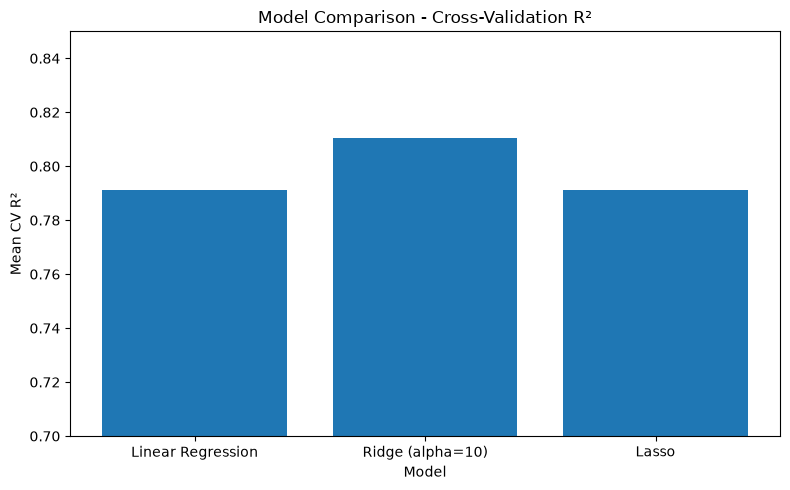

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["CV R2"]
)

plt.title("Model Comparison - Cross-Validation R²")
plt.xlabel("Model")
plt.ylabel("Mean CV R²")
plt.ylim(0.7, 0.85)

plt.tight_layout()
plt.show()

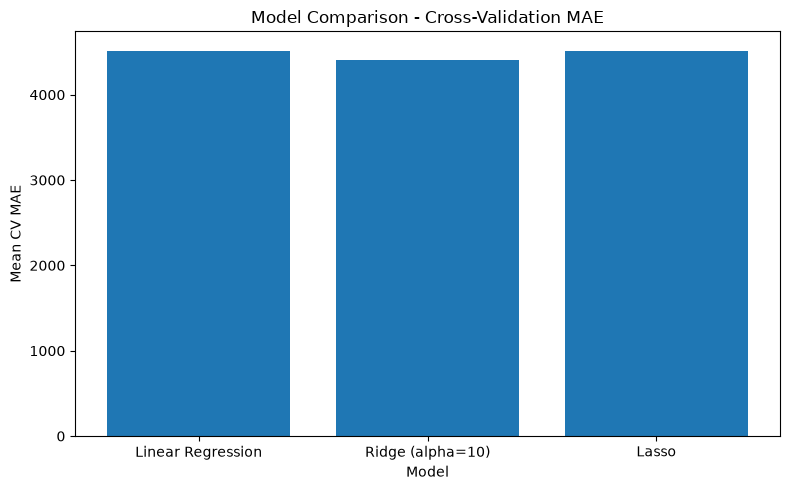

In [87]:
plt.figure(figsize=(8, 5))

plt.bar(
    model_comparison["Model"],
    model_comparison["CV MAE"]
)

plt.title("Model Comparison - Cross-Validation MAE")
plt.xlabel("Model")
plt.ylabel("Mean CV MAE")

plt.tight_layout()
plt.show()

In [88]:
final_model = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge (alpha=10)",
        "Lasso"
    ],
    "CV R2": [
        linear_cv_r2.mean(),
        ridge_grid.best_score_,
        lasso_cv_r2.mean()
    ],
    "CV MAE": [
        linear_cv_mae.mean(),
        ridge_cv_mae.mean(),
        lasso_cv_mae.mean()
    ],
    "Test R2": [
        r2,
        ridge_test_r2,
        lasso_test_r2
    ],
    "Test MAE": [
        mae,
        ridge_test_mae,
        lasso_test_mae
    ],
    "Test RMSE": [
        rmse,
        ridge_test_rmse,
        lasso_test_rmse
    ]
})

final_model

,Model,CV R2,CV MAE,Test R2,Test MAE,Test RMSE
0,Linear Regression,0.791032,4517.025969,0.899872,3526.636225,5303.298429
1,Ridge (alpha=10),0.810357,4401.085380,0.894539,4059.607329,5442.674834
2,Lasso,0.791056,4516.481728,0.899893,3526.362372,5302.718365


In [89]:
lasso_coefficients = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": lasso_model.named_steps["lasso"].coef_
})

lasso_coefficients["Absolute_Coefficient"] = (
    lasso_coefficients["Coefficient"].abs()
)

lasso_coefficients = lasso_coefficients.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

lasso_coefficients

,Feature,Coefficient,Absolute_Coefficient
1,Years_to_Promotion,-8571.875941,8571.875941
0,Internships_Completed,4459.710111,4459.710111
3,Current_Job_Level_Mid,2842.480343,2842.480343
2,Gender_Male,2811.406014,2811.406014


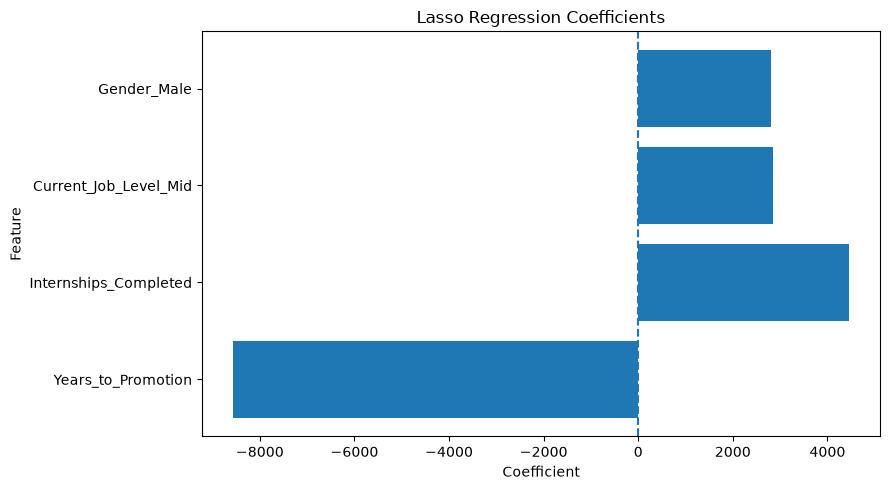

In [90]:
plt.figure(figsize=(9, 5))

plt.barh(
    lasso_coefficients["Feature"],
    lasso_coefficients["Coefficient"]
)

plt.axvline(0, linestyle="--")

plt.title("Lasso Regression Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [91]:
lasso_pred
y_test

359     94000
243     64000
253     72000
352     90000
332     88000
379     94000
52      46000
141    102000
107     76000
Name: Starting_Salary, dtype: int64

In [92]:
percentage_error = (
    np.abs(y_test.values - lasso_pred) / y_test.values
) * 100

print("Mean Absolute Percentage Error (MAPE): - 01_data_understanding.ipynb:5", percentage_error.mean(), "%")

Mean Absolute Percentage Error (MAPE): - 01_data_understanding.ipynb:5 5.260661240976518 %


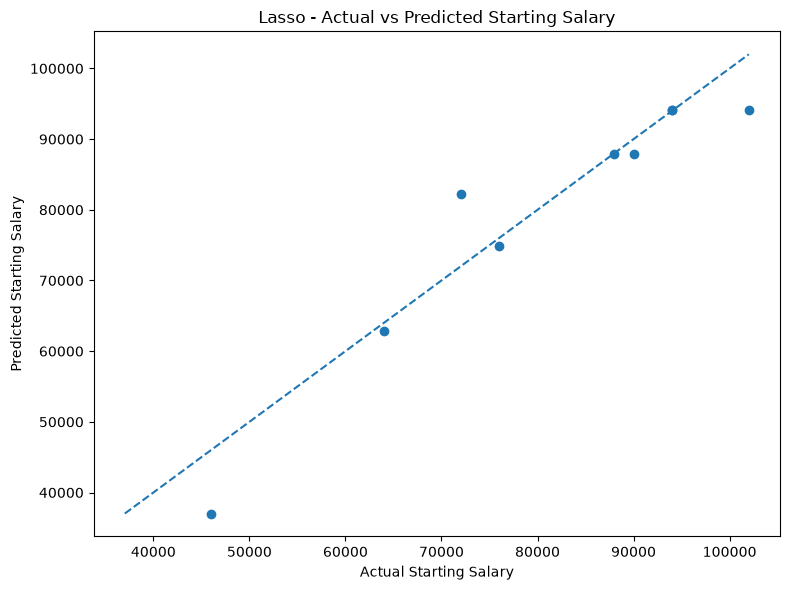

In [93]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, lasso_pred)

min_value = min(y_test.min(), lasso_pred.min())
max_value = max(y_test.max(), lasso_pred.max())

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Lasso - Actual vs Predicted Starting Salary")
plt.xlabel("Actual Starting Salary")
plt.ylabel("Predicted Starting Salary")

plt.tight_layout()
plt.show()

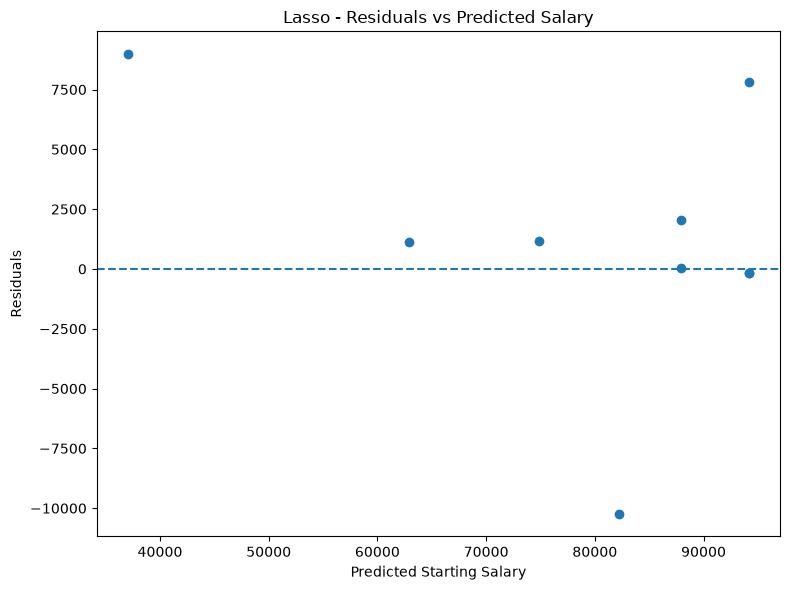

In [94]:
lasso_residuals = y_test.values - lasso_pred

plt.figure(figsize=(8, 6))

plt.scatter(lasso_pred, lasso_residuals)

plt.axhline(0, linestyle="--")

plt.title("Lasso - Residuals vs Predicted Salary")
plt.xlabel("Predicted Starting Salary")
plt.ylabel("Residuals")

plt.tight_layout()
plt.show()

## Final Model Selection 
Lasso Regression was selected as the final model for predicting starting salary.

The model achieved a Test R² of approximately 0.900, meaning that it explains around 90% of the variability in starting salaries in the test set. The model achieved a Test MAE of approximately $3,526, a Test RMSE of approximately $5,303, and a Mean Absolute Percentage Error (MAPE) of approximately 5.26%.

Although Ridge Regression achieved slightly better cross-validation performance, Lasso achieved the best performance on the test set while maintaining similar cross-validation results to Linear Regression. Lasso was therefore selected as the final model based on its predictive performance and its ability to provide interpretable coefficients.

## Key Predictors of Starting Salary 
The Lasso coefficients indicate that Years_to_Promotion has the strongest negative association with starting salary, while Internships_Completed has the strongest positive association. Current_Job_Level_Mid and Gender_Male also show positive associations with starting salary.

These coefficients represent statistical associations within the model and should not be interpreted as evidence of causation.

Marketing + Data Analytics 
The combination of marketing knowledge and data analytics provides a stronger basis for career and workforce decision-making. Rather than relying only on intuition or individual qualifications, organizations can use data to identify the characteristics associated with stronger career outcomes and support evidence-based decisions

Models of machine learning have used:
| Model                 | Type                               | Purpose                                      | Result              |
| --------------------- | ---------------------------------- | -------------------------------------------- | ------------------- |
| **Linear Regression** | Linear regression                  | Baseline model                               | Test R² ≈ **0.900** |
| **Ridge Regression**  | Regularized linear regression (L2) | Reduce effects of multicollinearity          | CV R² ≈ **0.810**   |
| **Lasso Regression**  | Regularized linear regression (L1) | Reduce multicollinearity + feature selection | Test R² ≈ **0.900** |




1. Linear Regression

This was our baseline model.

It gave us:

Test R²: 0.8999
Test MAE: $3,526.64
Test RMSE: $5,303.30

It establishes a benchmark against which we can compare the regularized models.

2. Ridge Regression

We introduced Ridge because our correlation matrix showed very strong multicollinearity between several variables.

We used GridSearchCV to find the best alpha:

Best α = 10

Results:

CV R²: 0.8104
CV MAE: $4,401
Test R²: 0.8945
Test MAE: $4,059.61
Test RMSE: $5,442.67

Ridge performed best during cross-validation, which indicates good generalization, but its final test performance was slightly worse than Linear/Lasso.

3. Lasso Regression

Lasso was particularly useful because it combines regression with feature selection.

It gave us:

Test R²: 0.8999
Test MAE: $3,526.36
Test RMSE: $5,302.72
MAPE: 5.26%

It also gave us interpretable coefficients:

Years_to_Promotion → −8,571.88
Internships_Completed → +4,459.71
Current_Job_Level_Mid → +2,842.48
Gender_Male → +2,811.41
🎯 So, in our project

The ML workflow was:

Linear Regression → Ridge Regression → Lasso Regression → Model Comparison → Final Model Selection

And we used:

Linear Regression as the baseline
Ridge to address multicollinearity
Lasso for regularization and interpretability

For the final project, I would present Lasso as the final selected model, while explicitly explaining that Ridge achieved the strongest cross-validation performance. This makes the model selection more defensible rather than simply choosing a model based on one test metric.

1. Linear Regression

This was our baseline model.

It gave us:

Test R²: 0.8999
Test MAE: $3,526.64
Test RMSE: $5,303.30

It establishes a benchmark against which we can compare the regularized models.

2. Ridge Regression

We introduced Ridge because our correlation matrix showed very strong multicollinearity between several variables.

We used GridSearchCV to find the best alpha:

Best α = 10

Results:

CV R²: 0.8104
CV MAE: $4,401
Test R²: 0.8945
Test MAE: $4,059.61
Test RMSE: $5,442.67

Ridge performed best during cross-validation, which indicates good generalization, but its final test performance was slightly worse than Linear/Lasso.

3. Lasso Regression

Lasso was particularly useful because it combines regression with feature selection.

It gave us:

Test R²: 0.8999
Test MAE: $3,526.36
Test RMSE: $5,302.72
MAPE: 5.26%

It also gave us interpretable coefficients:

Years_to_Promotion → −8,571.88
Internships_Completed → +4,459.71
Current_Job_Level_Mid → +2,842.48
Gender_Male → +2,811.41
🎯 So, in our project

The ML workflow was:

Linear Regression → Ridge Regression → Lasso Regression → Model Comparison → Final Model Selection

And we used:

Linear Regression as the baseline
Ridge to address multicollinearity
Lasso for regularization and interpretability

For the final project, I would present Lasso as the final selected model, while explicitly explaining that Ridge achieved the strongest cross-validation performance. This makes the model selection more defensible rather than simply choosing a model based on one test metric.

## Model Limitations 
The dataset is relatively small, with only 44 observations, which limits the generalizability of the model. In addition, several variables show strong correlations with each other, indicating potential multicollinearity. The model should therefore be interpreted as an analytical tool rather than a definitive salary prediction system.

The gender coefficient should also be interpreted carefully. The observed association does not establish that gender causes differences in starting salary and may reflect other factors present in the dataset.

## Marketing & Data Analytics Insights:

 1. Practical experience matters

Internships and completed projects show strong positive associations with starting salary, suggesting that practical experience and portfolio development may play an important role in early career outcomes.

2. Employability is strongly connected to career outcomes

Job offers and career satisfaction are strongly associated with starting salary, indicating that employability and career progression are interconnected.

3. Career outcomes are multidimensional

The correlation analysis shows strong relationships between academic performance, practical experience, professional skills, networking and career outcomes. This suggests that salary and career success cannot be explained by a single factor.

4. Data can support career and marketing decisions

Predictive modeling demonstrates how data analytics can transform descriptive information about professionals into actionable insights for workforce planning, talent development and career strategy.

5. Practical experience can be a strategic focus

From a career development perspective, internships and projects emerge as particularly relevant variables. Organizations, educational institutions and professionals could therefore benefit from emphasizing practical experience alongside academic qualifications.

Overall Conclusion

This project demonstrates how data analytics can be applied to marketing and career-related questions to move from descriptive analysis to predictive and actionable insights. The analysis identified strong relationships between professional development, employability and starting salary, while the Lasso model achieved approximately 90% explanatory power and a 5.26% mean absolute percentage error on the test data.

The results highlight the value of combining domain knowledge in marketing with analytical techniques to support evidence-based decision-making.

Marketing question → Data → EDA → Statistical relationships → Machine Learning → Insights → Business recommendations.